# Cooling Scenario Results Analysis

This notebook summarizes the results of Citi Bike heat exposure analyses under baseline and cooling-intervention scenarios. It compares trip-level UTCI exposure, spatial concentration of exposed segments, length-weighted rider thermal load, and heat-exposed kilometers across different intervention intensities.

Loads the two GeoPackages.

Join the 150‐segment layer to the full network to pull in length_m and count.

Sum up lengths (converted to km) and trip counts.

Calculate each as a percentage of the network total.

In [1]:
import geopandas as gpd

# 1. IDs to exclude
EXCLUDE_IDS = {
    58251, 58267, 27, 53086, 56194, 58345, 10148, 53324, 9712,
    62, 70, 58260, 12, 52736, 29566, 28997, 58347, 51655,
    58339, 58341, 58237, 58238, 22084, 41173
}

# 2. File paths
top1000_path  = r"C:\Users\Agustin\Documents\2025summer\sanity_check\results\temp_segments\top1000_high_utci_segments_neat_GLOBAL.gpkg"
network_path = r"C:\Users\Agustin\Documents\2025summer\sanity_check\results\temp_segments\street_network_with_counts_and_length.gpkg"

# 3. Load layers
top1000  = gpd.read_file(top1000_path)
network = gpd.read_file(network_path)[['seg_id', 'length_m', 'count']]

# 4. Exclude unwanted segments
top1000  = top1000 [~top1000 ['seg_id'].isin(EXCLUDE_IDS)]
network = network[~network['seg_id'].isin(EXCLUDE_IDS)]

# 5. Rename network 'count' to avoid confusion
network = network.rename(columns={'count':'trip_count'})

# 6. Merge Top-1000 onto the full network
top1000_full = top1000.merge(network, on='seg_id', how='left')

# 7. Compute length & trip metrics
total_length_top400_km  = top1000_full['length_m'].sum() / 1000
total_length_network_km = network['length_m'].sum() / 1000
pct_length              = total_length_top1000_km / total_length_network_km * 100

total_trips_top1000      = top1000_full['trip_count'].sum()
total_trips_network     = network['trip_count'].sum()
pct_trips               = total_trips_top1000 / total_trips_network * 100

# 8. Compute heat-exposed kilometers (trip_count × length_m)
heatex_km_top1000 = (top1000_full['trip_count'] * top1000_full['length_m']).sum() / 1000
heatex_km_net   = (network      ['trip_count'] * network      ['length_m']).sum() / 1000
pct_heatex_km   = heatex_km_top1000 / heatex_km_net * 100

# 9. Print all results
print(f"Top-1000 segments total length:       {total_length_top1000_km:.2f} km")
print(f"Entire network total length:         {total_length_network_km:.2f} km")
print(f"% of network length in Top-1000:      {pct_length:.2f}%\n")

print(f"Top-1000 segments trip count:         {total_trips_top1000:,}")
print(f"Entire network trip count:           {total_trips_network:,}")
print(f"% of all counts in Top-1000:           {pct_trips:.2f}%\n")

print(f"Top-1000 heat-exposed km:              {heatex_km_top1000:,.1f} km")
print(f"Entire network heat-exposed km:       {heatex_km_net:,.1f} km")
print(f"% of heat-exposed km in Top-1000:      {pct_heatex_km:.2f}%")


Top-1000 segments total length:       150.80 km
Entire network total length:         10090.74 km
% of network length in Top-1000:      1.49%

Top-1000 segments trip count:         23,583,637
Entire network trip count:           48,233,408
% of all counts in Top-1000:           48.89%

Top-1000 heat-exposed km:              4,278,187.7 km
Entire network heat-exposed km:       8,329,736.2 km
% of heat-exposed km in Top-1000:      51.36%


CALCULATE LENGTH OF SEGMENTS IN "C:\Users\Agustin\Documents\2025summer\sanity_check\results\temp_segments\street_network_with_counts.gpkg"

This step prepares the street-network results for exposure calculations by computing segment length in meters. The resulting GeoPackage contains segment IDs, trip counts, segment lengths, and geometry. These fields are required for later length-weighted exposure metrics.

In [2]:
import geopandas as gpd
from pathlib import Path

# Paths
INPUT_FP  = Path(r"C:\Users\Agustin\Documents\2025summer\sanity_check\results\temp_segments\street_network_with_counts.gpkg")
OUTPUT_FP = INPUT_FP.parent / "street_network_with_counts_and_length.gpkg"

# Load and reproject (ensures geometry length is in meters)
gdf = gpd.read_file(INPUT_FP).to_crs(32118)

# Compute segment length in meters
gdf["length_m"] = gdf.geometry.length

# Drop the utci column
if "utci" in gdf.columns:
    gdf = gdf.drop(columns=["utci"])

# Select and order columns: seg_id, count, length_m, then geometry
cols = ["seg_id", "count", "length_m", "geometry"]
gdf = gdf[cols]

# Save new GeoPackage
gdf.to_file(OUTPUT_FP, driver="GPKG")
print("Wrote:", OUTPUT_FP)


Wrote: C:\Users\Agustin\Documents\2025summer\sanity_check\results\temp_segments\street_network_with_counts_and_length.gpkg


## Important note: Ideas 1–4 were developed as preliminary exploratory metrics for comparing the baseline and cooling-intervention scenarios. These metrics were calculated for the base scenario and for the Top-150, Top-400, and Top-1000 high-UTCI segment intervention groups, each under 3°C, 5°C, and 10°C UTCI reduction assumptions. This produced 10 total scenarios: one baseline scenario plus nine cooling scenarios. Some of these metrics were useful during exploratory analysis but were not included in the final paper.

## Trip-Level Danger-Zone Share

IDEA 1 – How often do riders enter the danger zone (mean-UTCI version)? and Metric: The share of rides whose mean UTCI ≥ 32 °C and ≥ 38 °C. Why: Provides a clear headline—“X % of Citi Bike trips exceed 32 °C/38 °C heat stress”—and shows with:

This section calculates the share of Citi Bike trips whose mean UTCI exceeds selected heat-stress thresholds. Results are computed by hour and summarized for both the full day and the core daytime period from 08:00 to 19:00.

In [2]:
# ─── Cell 1 · SETUP ──────────────────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Paths & constants for the 3°C cooling scenario (Top-1000)
UTCI_RESULTS = Path(
    r"C:\Users\Agustin\Documents\2025summer\sanity_check\cooling_scenario\top1000\3degrees\utci_results"
)
ANA_DIR = Path(
    r"C:\Users\Agustin\Documents\2025summer\sanity_check\cooling_scenario\top1000\3degrees\analysis"
)
ANA_DIR.mkdir(parents=True, exist_ok=True)

HOURS      = [f"{h:02d}00" for h in range(24)]
CORE_HOURS = [f"{h:02d}00" for h in range(8, 20)]  # 08:00–19:00
THRESHOLDS = [32.0, 38.0]   # °C
LABELS     = {32.0: "mean UTCI ≥ 32 °C", 38.0: "mean UTCI ≥ 38 °C"}

print("Analysis outputs →", ANA_DIR)


Analysis outputs → C:\Users\Agustin\Documents\2025summer\sanity_check\cooling_scenario\top1000\3degrees\analysis


In [3]:
# ─── Cell 2 · COMPUTE “DANGER-ZONE” SHARE & PRINT GLOBAL + CORE-DAY ─────
totals, shares32, shares38 = [], [], []

for hh in HOURS:
    fp = UTCI_RESULTS / f"mean_utci_{hh}.csv"
    if not fp.exists():
        totals.append(0)
        shares32.append(0)
        shares38.append(0)
        continue

    df = pd.read_csv(fp)
    n   = len(df)
    m32 = (df["mean_utci"] >= THRESHOLDS[0]).sum()
    m38 = (df["mean_utci"] >= THRESHOLDS[1]).sum()

    totals.append(n)
    shares32.append(m32 / n * 100 if n else 0)
    shares38.append(m38 / n * 100 if n else 0)

res = pd.DataFrame({
    "hour":         HOURS,
    "total_trips":  totals,
    "share_32°C":   shares32,
    "share_38°C":   shares38,
})

# save CSV
out_csv = ANA_DIR / "danger_zone_meanutci_share_by_hour.csv"
res.to_csv(out_csv, index=False)
print("CSV saved →", out_csv)

# Full-day summary
total_trips = res["total_trips"].sum()
exp32       = (res["share_32°C"] * res["total_trips"] / 100).sum()
exp38       = (res["share_38°C"] * res["total_trips"] / 100).sum()
full32      = exp32 / total_trips * 100 if total_trips else 0
full38      = exp38 / total_trips * 100 if total_trips else 0

print(f"\nAcross the full day:")
print(f" • {full32:.1f}% of trips ≥ 32 °C")
print(f" • {full38:.1f}% of trips ≥ 38 °C")

# Core-day summary (08:00–19:00)
core = res[res["hour"].isin(CORE_HOURS)]
core_trips = core["total_trips"].sum()
core_exp32  = (core["share_32°C"] * core["total_trips"] / 100).sum()
core_exp38  = (core["share_38°C"] * core["total_trips"] / 100).sum()
core32      = core_exp32 / core_trips * 100 if core_trips else 0
core38      = core_exp38 / core_trips * 100 if core_trips else 0

print(f"\nDuring core daytime (08:00–19:00):")
print(f" • {core32:.1f}% of trips ≥ 32 °C")
print(f" • {core38:.1f}% of trips ≥ 38 °C")


CSV saved → C:\Users\Agustin\Documents\2025summer\sanity_check\cooling_scenario\top1000\3degrees\analysis\danger_zone_meanutci_share_by_hour.csv

Across the full day:
 • 55.4% of trips ≥ 32 °C
 • 15.6% of trips ≥ 38 °C

During core daytime (08:00–19:00):
 • 74.0% of trips ≥ 32 °C
 • 20.8% of trips ≥ 38 °C


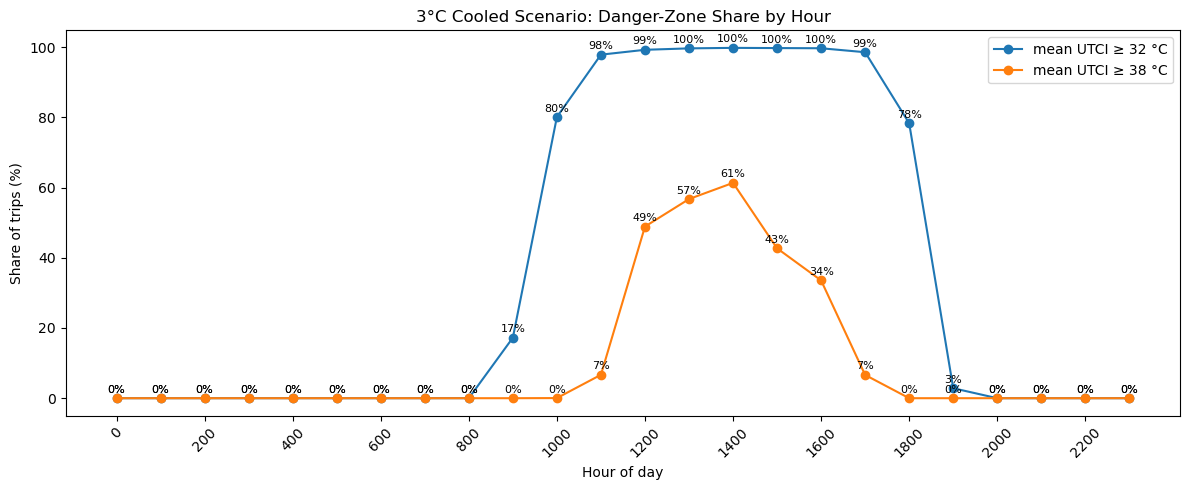

Annotated plot saved → C:\Users\Agustin\Documents\2025summer\sanity_check\cooling_scenario\top1000\3degrees\analysis\danger_zone_meanutci_share_by_hour_annotated.png


In [4]:
# ─── Cell 3 · PLOT ANNOTATED LINE CHART ───────────────────────────────
res = pd.read_csv(out_csv)
hours = res["hour"].tolist()
x = np.arange(len(hours))

plt.figure(figsize=(12, 5))
for thresh in THRESHOLDS:
    col = f"share_{int(thresh)}°C"
    y   = res[col].values
    plt.plot(x, y, marker="o", label=LABELS[thresh])
    for xi, yi in zip(x, y):
        plt.text(xi, yi+1, f"{yi:.0f}%", ha="center", va="bottom", fontsize=8)

plt.xlabel("Hour of day")
plt.ylabel("Share of trips (%)")
plt.title("3°C Cooled Scenario: Danger-Zone Share by Hour")

ticks = x[::2]
plt.xticks(ticks, [hours[i] for i in ticks], rotation=45)
plt.legend()
plt.tight_layout()

out_png = ANA_DIR / "danger_zone_meanutci_share_by_hour_annotated.png"
plt.savefig(out_png, dpi=150)
plt.show()
print("Annotated plot saved →", out_png)

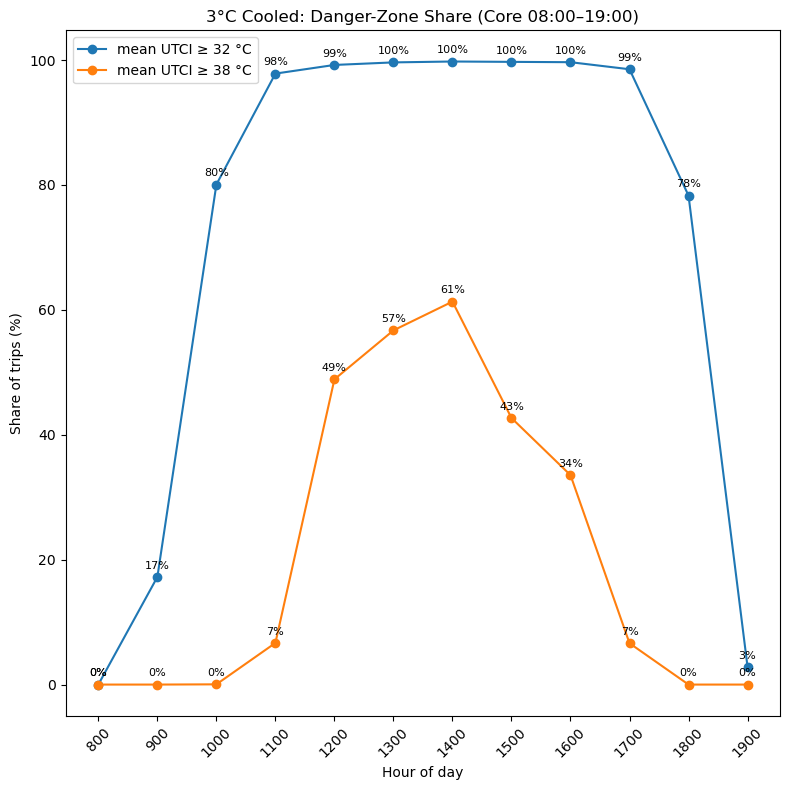

Square core-day plot saved → C:\Users\Agustin\Documents\2025summer\sanity_check\cooling_scenario\top1000\3degrees\analysis\danger_zone_coreday_square.png


In [5]:
# ─── Cell 3 (Core-Day) · SQUARE PLOT ───────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Load data
ANA_DIR  = Path(r"C:\Users\Agustin\Documents\2025summer\sanity_check\cooling_scenario\top1000\3degrees\analysis")
csv_path = ANA_DIR / "danger_zone_meanutci_share_by_hour.csv"
res      = pd.read_csv(csv_path)

# Filter core hours numerically
res["hour_num"] = res["hour"].astype(int)
core = res[(res["hour_num"] >= 800) & (res["hour_num"] <= 1900)].reset_index(drop=True)

# Prepare
x     = np.arange(len(core))
hours = core["hour_num"].astype(str).tolist()

# Create a square figure
plt.figure(figsize=(8, 8))

for thresh in [32.0, 38.0]:
    col = f"share_{int(thresh)}°C"
    y   = core[col].values
    plt.plot(x, y, marker="o", label=f"mean UTCI ≥ {int(thresh)} °C")
    for xi, yi in zip(x, y):
        plt.text(xi, yi + 1, f"{yi:.0f}%", ha="center", va="bottom", fontsize=8)

plt.xlabel("Hour of day")
plt.ylabel("Share of trips (%)")
plt.title("3°C Cooled: Danger-Zone Share (Core 08:00–19:00)")

plt.xticks(x, hours, rotation=45)
plt.legend()
plt.tight_layout()

out_png = ANA_DIR / "danger_zone_coreday_square.png"
plt.savefig(out_png, dpi=150)
plt.show()
print("Square core-day plot saved →", out_png)


END IDEA 1

## Trip Mean UTCI Distribution

IDEA 2 - This section compiles all trip-level mean UTCI values and plots their cumulative distribution. The resulting curve shows the distribution of thermal exposure across trips and highlights median, 90th percentile, and 95th percentile exposure levels.

In [22]:
# ─── Cell 1 · SETUP ──────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Paths for the cooled scenario
UTCI_RESULTS = Path(r"C:\Users\Agustin\Documents\2025summer\sanity_check\cooling_scenario\top1000\3degrees\utci_results")
ANA_DIR      = Path(r"C:\Users\Agustin\Documents\2025summer\sanity_check\cooling_scenario\top1000\3degrees\analysis")
ANA_DIR.mkdir(parents=True, exist_ok=True)

print("Analysis outputs →", ANA_DIR)


Analysis outputs → C:\Users\Agustin\Documents\2025summer\sanity_check\cooling_scenario\top1000\3degrees\analysis


In [23]:
# ─── Cell 2 · COMPILE ALL TRIP MEAN-UTCI VALUES ──────────────────────────
records = []
for fp in sorted(UTCI_RESULTS.glob("mean_utci_*.csv")):
    df = pd.read_csv(fp, usecols=["ride_id", "mean_utci"])
    records.append(df)

all_mean = pd.concat(records, ignore_index=True)
print(f"Loaded {len(all_mean):,} trip records")


Loaded 4,643,631 trip records


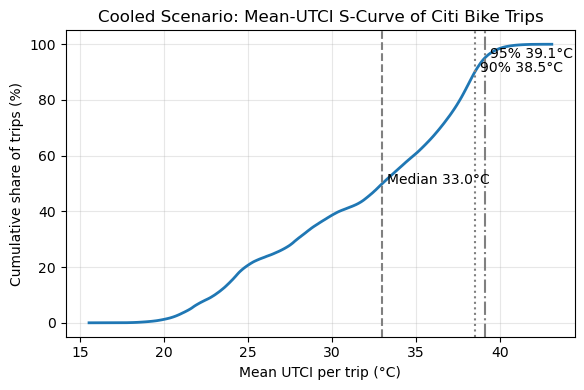

Plot saved → C:\Users\Agustin\Documents\2025summer\sanity_check\cooling_scenario\top1000\3degrees\analysis\trip_mean_utci_cdf_cooled.png


In [24]:
# ─── Cell 3 · PLOT CUMULATIVE DISTRIBUTION (S‐Curve) ──────────────────────
values = np.sort(all_mean["mean_utci"].to_numpy())
cum    = np.linspace(0, 100, len(values), endpoint=False)

# Percentiles for annotation
p50, p90, p95 = np.percentile(values, [50, 90, 95])

plt.figure(figsize=(6, 4))
plt.plot(values, cum, lw=2)
plt.axvline(p50, color="grey", ls="--"); plt.text(p50+0.3, 50, f"Median {p50:.1f}°C")
plt.axvline(p90, color="grey", ls=":") ; plt.text(p90+0.3, 90, f"90% {p90:.1f}°C")
plt.axvline(p95, color="grey", ls="-."); plt.text(p95+0.3, 95, f"95% {p95:.1f}°C")

plt.xlabel("Mean UTCI per trip (°C)")
plt.ylabel("Cumulative share of trips (%)")
plt.title("Cooled Scenario: Mean‐UTCI S‐Curve of Citi Bike Trips")
plt.grid(alpha=0.3)
plt.tight_layout()

out_png = ANA_DIR / "trip_mean_utci_cdf_cooled.png"
plt.savefig(out_png, dpi=150)
plt.show()
print("Plot saved →", out_png)


END IDEA 2

## Spatial Concentration of Exposure

FOR THIS IDEA, I EXCLUDED CERTAIN SEGMENT IDS FOR THE ACCURACY OF THE ANALYSIS. THIS IS THE ONLY IDEA WHERE THIS NEEDED TO BE DONE

This section evaluates whether heat exposure is concentrated on a small number of street segments. Segment exposure is calculated as trip count multiplied by segment length. A Lorenz curve and concentration shares are then used to quantify how much exposure is carried by the top 1%, 5%, and 10% of exposed segments.

In [31]:
# ─── Cell 1 · SETUP ──────────────────────────────────────────────────────
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Paths for cooled scenario
DATA_DIR    = Path(r"C:\Users\Agustin\Documents\2025summer\sanity_check\cooling_scenario\top1000\3degrees\results")
ANA_DIR     = Path(r"C:\Users\Agustin\Documents\2025summer\sanity_check\cooling_scenario\top1000\3degrees\analysis")
ANA_DIR.mkdir(parents=True, exist_ok=True)

# Use the length‐augmented network you created
GPKG_FP     = DATA_DIR / "3degrees_top1000_street_network_with_counts_and_length.gpkg"

# IDs you manually excluded earlier
EXCLUDE_IDS = {
    58251,58267,27,53086,56194,58345,10148,53324,9712,62,70,
    58260,12,52736,29566,28997,58347,51655,58339,58341,58237,
    58238,22084,41173
}

# Gini helper
def gini(x):
    x = np.sort(np.asarray(x, dtype=float))
    n = len(x)
    return 0.0 if n == 0 or x.sum() == 0 else (n + 1 - 2 * (np.cumsum(x).sum() / x.sum())) / n

print("Data →", GPKG_FP)
print("Analysis outputs →", ANA_DIR)

Data → C:\Users\Agustin\Documents\2025summer\sanity_check\cooling_scenario\top1000\3degrees\results\3degrees_top1000_street_network_with_counts_and_length.gpkg
Analysis outputs → C:\Users\Agustin\Documents\2025summer\sanity_check\cooling_scenario\top1000\3degrees\analysis


In [32]:
# ─── Cell 2 · COMPUTE LENGTH-WEIGHTED EXPOSURE ─────────────────────────
# Load, drop excluded, compute exposure = count × length_m
gdf = gpd.read_file(GPKG_FP).to_crs(32118)
gdf = gdf[~gdf["seg_id"].isin(EXCLUDE_IDS)]

gdf["exposure"] = gdf["count"] * gdf["length_m"]

# Keep only segments with positive exposure
expo = gdf.loc[gdf["exposure"] > 0, ["seg_id", "exposure"]]
expo = expo.set_index("seg_id")["exposure"]

print(f"Filtered to {len(expo):,} segments with exposure > 0")


Filtered to 15,619 segments with exposure > 0


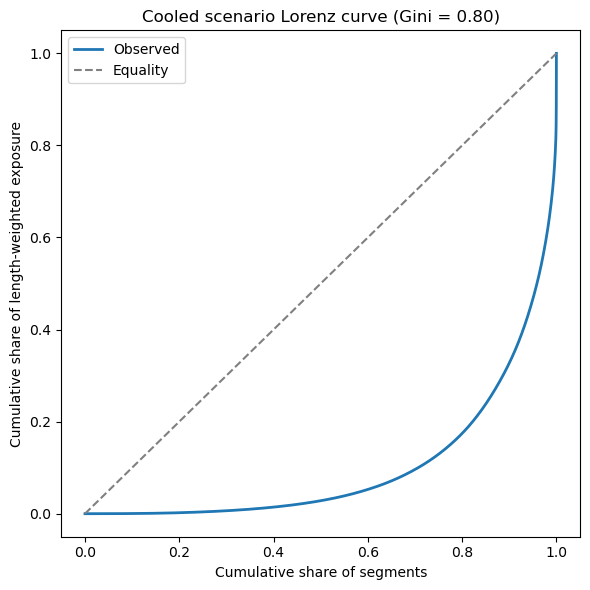

Plot saved → C:\Users\Agustin\Documents\2025summer\sanity_check\cooling_scenario\top1000\3degrees\analysis\lorenz_length_weighted_exposure_filtered_cooled.png
Total exposed segments: 15,619
Top 1% carry 31.6% of exposure
Top 5% carry 53.4% of exposure
Top 10% carry 67.3% of exposure


In [33]:
# ─── Cell 3 · LORENZ CURVE & CONCENTRATION SHARES ──────────────────────
# 3.1 Lorenz
x        = np.sort(expo.values)
cum_x    = np.cumsum(x) / x.sum()
lorenz_p = np.linspace(0, 1, len(x), endpoint=False)
gini_coef = gini(x)

# 3.2 Top‐p concentration
x_desc   = x[::-1]
cum_desc = np.cumsum(x_desc) / x_desc.sum()
def top_share(p):
    idx = int(np.ceil(p * len(cum_desc))) - 1
    return cum_desc[max(idx, 0)]

s1  = top_share(0.01)
s5  = top_share(0.05)
s10 = top_share(0.10)

# 3.3 Plot
plt.figure(figsize=(6, 6))
plt.plot(lorenz_p, cum_x, lw=2, label="Observed")
plt.plot([0, 1], [0, 1], ls="--", color="grey", label="Equality")
plt.xlabel("Cumulative share of segments")
plt.ylabel("Cumulative share of length-weighted exposure")
plt.title(f"Cooled scenario Lorenz curve (Gini = {gini_coef:.2f})")
plt.legend()
plt.tight_layout()
out_png = ANA_DIR / "lorenz_length_weighted_exposure_filtered_cooled.png"
plt.savefig(out_png, dpi=150)
plt.show()
print("Plot saved →", out_png)

# 3.4 Statistics
print(f"Total exposed segments: {len(x):,}")
print(f"Top 1% carry {s1*100:4.1f}% of exposure")
print(f"Top 5% carry {s5*100:4.1f}% of exposure")
print(f"Top 10% carry {s10*100:4.1f}% of exposure")


END IDEA 3

## Length-Weighted Rider Thermal Load

IDEA 4 - This section calculates the length-weighted average UTCI experienced by riders. Weighting by trip length gives longer trips more influence, producing an exposure metric that better represents cumulative rider thermal burden than a simple average across trips.

In [40]:
# ─── Cell 1 · SETUP ──────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Paths for the cooled scenario
UTCI_RESULTS = Path(r"C:\Users\Agustin\Documents\2025summer\sanity_check\cooling_scenario\top1000\3degrees\utci_results")
ANA_DIR      = Path(r"C:\Users\Agustin\Documents\2025summer\sanity_check\cooling_scenario\top1000\3degrees\analysis")
ANA_DIR.mkdir(parents=True, exist_ok=True)

HOURS      = [f"{h:02d}00" for h in range(24)]
DAY_WINDOW = range(8, 20)  # 08:00–19:00

print("Analysis outputs →", ANA_DIR)


Analysis outputs → C:\Users\Agustin\Documents\2025summer\sanity_check\cooling_scenario\top1000\3degrees\analysis


In [41]:
# ─── Cell 2 · HOURLY LENGTH-WEIGHTED AVERAGE UTCI ─────────────────────────
records = []
for hh in HOURS:
    fp = UTCI_RESULTS / f"mean_utci_{hh}.csv"
    if not fp.exists():
        records.append({"hour": hh, "weighted_utci": np.nan})
        continue

    df = pd.read_csv(fp)
    total_len = df["trip_len_m"].sum()
    wavg = (df["trip_len_m"] * df["mean_utci"]).sum() / total_len if total_len else np.nan
    records.append({"hour": hh, "weighted_utci": wavg})

hourly_df = pd.DataFrame(records)
hourly_df["hour_int"] = hourly_df["hour"].str[:2].astype(int)
hourly_df.sort_values("hour_int", inplace=True)

# Save hourly results
out_hourly = ANA_DIR / "hourly_weighted_avg_utci.csv"
hourly_df.to_csv(out_hourly, index=False)
print("Saved hourly weighted UTCI →", out_hourly)


Saved hourly weighted UTCI → C:\Users\Agustin\Documents\2025summer\sanity_check\cooling_scenario\top1000\3degrees\analysis\hourly_weighted_avg_utci.csv


In [42]:
# ─── Cell 3 · DAILY & DAYTIME SUMMARY ─────────────────────────────────────
# Overall and daytime weighted averages
sum_len, sum_utci = 0.0, 0.0
for hh in HOURS:
    fp = UTCI_RESULTS / f"mean_utci_{hh}.csv"
    if not fp.exists(): continue
    df = pd.read_csv(fp)
    sum_len  += df["trip_len_m"].sum()
    sum_utci += (df["trip_len_m"] * df["mean_utci"]).sum()
overall_wavg = sum_utci / sum_len

d_len, d_utci = 0.0, 0.0
for h in DAY_WINDOW:
    fp = UTCI_RESULTS / f"mean_utci_{h:02d}00.csv"
    if not fp.exists(): continue
    df = pd.read_csv(fp)
    d_len  += df["trip_len_m"].sum()
    d_utci += (df["trip_len_m"] * df["mean_utci"]).sum()
daytime_wavg = d_utci / d_len

summary = pd.DataFrame([
    {"period": "Overall (00–23)",    "weighted_utci": overall_wavg},
    {"period": "Daytime (08–19)",    "weighted_utci": daytime_wavg},
])
out_summary = ANA_DIR / "daily_weighted_avg_utci_summary.csv"
summary.to_csv(out_summary, index=False)
print("Saved daily UTCI summary →", out_summary)


Saved daily UTCI summary → C:\Users\Agustin\Documents\2025summer\sanity_check\cooling_scenario\top1000\3degrees\analysis\daily_weighted_avg_utci_summary.csv


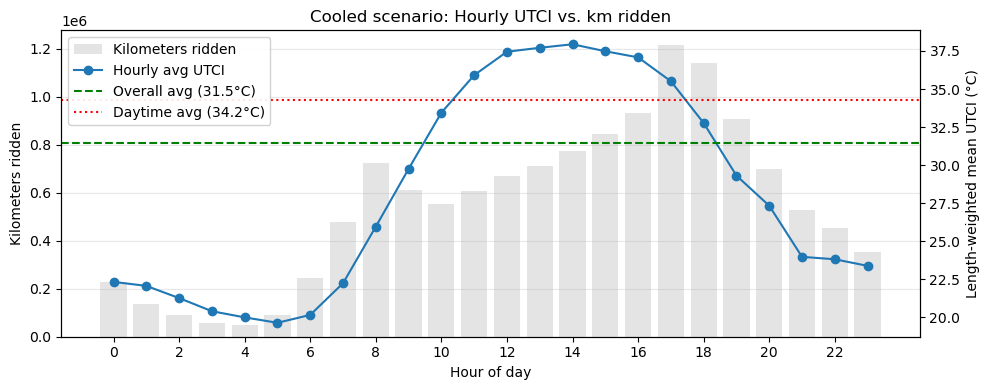

Figure saved → C:\Users\Agustin\Documents\2025summer\sanity_check\cooling_scenario\top1000\3degrees\analysis\weighted_utci_with_km_histogram_cooled.png


In [43]:
# ─── Cell 4 · VISUALIZE UTCI & KM-RIDDEN HISTOGRAM ───────────────────────
# Load hourly and compute km ridden
hourly = pd.read_csv(ANA_DIR / "hourly_weighted_avg_utci.csv")
hourly["km_ridden"] = 0.0
for i, row in hourly.iterrows():
    hh = f"{int(row.hour_int):02d}00"
    fp = UTCI_RESULTS / f"mean_utci_{hh}.csv"
    if fp.exists():
        df = pd.read_csv(fp)
        hourly.at[i, "km_ridden"] = df["trip_len_m"].sum() / 1000

# Load summary averages
summary = pd.read_csv(ANA_DIR / "daily_weighted_avg_utci_summary.csv").set_index("period")["weighted_utci"]
overall = summary["Overall (00–23)"]
daytime = summary["Daytime (08–19)"]

fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.bar(hourly.hour_int, hourly.km_ridden, color="lightgrey", alpha=0.6, label="Kilometers ridden")
ax1.set_xlabel("Hour of day")
ax1.set_ylabel("Kilometers ridden")
ax1.set_xticks(range(0,24,2))
ax1.grid(axis="y", alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(hourly.hour_int, hourly.weighted_utci, color="tab:blue", marker="o", label="Hourly avg UTCI")
ax2.axhline(overall, color="green", ls="--", lw=1.5, label=f"Overall avg ({overall:.1f}°C)")
ax2.axhline(daytime, color="red",   ls=":",  lw=1.5, label=f"Daytime avg ({daytime:.1f}°C)")
ax2.set_ylabel("Length-weighted mean UTCI (°C)")

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc="upper left", framealpha=0.9)

plt.title("Cooled scenario: Hourly UTCI vs. km ridden")
plt.tight_layout()
out_png = ANA_DIR / "weighted_utci_with_km_histogram_cooled.png"
plt.savefig(out_png, dpi=150)
plt.show()
print("Figure saved →", out_png)


In [44]:
# ─── Cell X: Print Cooled‐Scenario km ridden & UTCI ─────────────────
import pandas as pd
from pathlib import Path

# Paths for cooled scenario
ANA_DIR  = Path(r"C:\Users\Agustin\Documents\2025summer\sanity_check\cooling_scenario\top1000\3degrees\analysis")
UTCI_DIR = Path(r"C:\Users\Agustin\Documents\2025summer\sanity_check\cooling_scenario\top1000\3degrees\utci_results")

# Load the hourly UTCI CSV (cooled scenario)
hourly = pd.read_csv(ANA_DIR / "hourly_weighted_avg_utci.csv")

# Ensure hour_int exists
if "hour_int" not in hourly.columns:
    hourly["hour_int"] = hourly["hour"].str[:2].astype(int)

# Compute km ridden per hour using the correct '00' suffix
kms = []
for hh in hourly["hour_int"]:
    fp = UTCI_DIR / f"mean_utci_{hh:02d}00.csv"   # note the '00' suffix
    if fp.exists():
        df = pd.read_csv(fp)
        kms.append(df["trip_len_m"].sum() / 1000)  # meters → km
    else:
        kms.append(0.0)
hourly["km_ridden"] = kms

# Print the table
print(f"{'Hour':<4} | {'Km ridden':>12} | {'Weighted UTCI':>14}")
print("-" * 40)
for _, row in hourly.iterrows():
    hr   = int(row["hour_int"])
    km   = row["km_ridden"]
    wutc = row["weighted_utci"]
    print(f"{hr:02d}   | {km:12,.1f} | {wutc:14.2f}")


Hour |    Km ridden |  Weighted UTCI
----------------------------------------
00   |    229,517.5 |          22.33
01   |    137,180.0 |          22.07
02   |     90,774.3 |          21.27
03   |     56,927.9 |          20.41
04   |     48,889.8 |          20.00
05   |     90,407.6 |          19.65
06   |    246,352.5 |          20.17
07   |    477,609.8 |          22.25
08   |    725,690.3 |          25.96
09   |    610,521.4 |          29.76
10   |    550,984.6 |          33.44
11   |    607,482.1 |          35.91
12   |    668,818.5 |          37.45
13   |    710,441.4 |          37.71
14   |    775,581.6 |          37.94
15   |    842,903.9 |          37.48
16   |    931,359.7 |          37.08
17   |  1,215,752.8 |          35.51
18   |  1,140,248.1 |          32.77
19   |    906,140.0 |          29.31
20   |    700,406.3 |          27.33
21   |    525,971.4 |          23.98
22   |    454,317.1 |          23.82
23   |    353,744.1 |          23.39


END IDEA 4

## Compare Cooling Scenarios

This section compares baseline and cooling scenarios across the main exposure metrics: danger-zone trip share, trip-level UTCI distribution, spatial concentration of exposure, and length-weighted average UTCI.

#### IDEA 1 - Danger-Zone Share Comparison

In [62]:
import pandas as pd

data = {
    "Scenario": [
        "Base",
        "3°C (150)",
        "5°C (150)",
        "10°C (150)",
        "3°C (400)",
        "5°C (400)",
        "10°C (400)",
        "3°C (1000)",
        "5°C (1000)",
        "10°C (1000)",
    ],
    "Full-Day ≥32°C (%)": [
        57.7, 57.0, 56.0, 52.3, 56.8, 55.2, 50.3, 55.4, 52.2, 43.7,
    ],
    "Full-Day ≥38°C (%)": [
        24.4, 20.3, 18.5, 16.2, 19.2, 16.7, 13.8, 15.6, 12.0, 8.9,
    ],
    "Core-Day ≥32°C (%)": [
        77.1, 76.2, 74.9, 69.9, 75.9, 73.8, 67.2, 74.0, 69.8, 58.4,
    ],
    "Core-Day ≥38°C (%)": [
        32.6, 27.2, 24.7, 21.6, 25.7, 22.3, 18.5, 20.8, 16.1, 11.9,
    ],
}

# Build and transpose so that each Scenario is a row
df = pd.DataFrame(data).set_index("Scenario").T

# Now transpose back so that Scenario becomes the index and Metrics the columns
df = df.T
df.index.name = "Scenario"

print(df.to_string())


             Full-Day ≥32°C (%)  Full-Day ≥38°C (%)  Core-Day ≥32°C (%)  Core-Day ≥38°C (%)
Scenario                                                                                   
Base                       57.7                24.4                77.1                32.6
3°C (150)                  57.0                20.3                76.2                27.2
5°C (150)                  56.0                18.5                74.9                24.7
10°C (150)                 52.3                16.2                69.9                21.6
3°C (400)                  56.8                19.2                75.9                25.7
5°C (400)                  55.2                16.7                73.8                22.3
10°C (400)                 50.3                13.8                67.2                18.5
3°C (1000)                 55.4                15.6                74.0                20.8
5°C (1000)                 52.2                12.0                69.8         

#### IDEA 2 - Mean UTCI Distribution Comparison

In [61]:
import pandas as pd

data = {
    "Metric": [
        "Median (°C)",
        "90th percentile (°C)",
        "95th percentile (°C)",
    ],
    "Base":          [33.8, 39.1, 39.6],
    "3°C (150)":     [33.4, 38.9, 39.4],
    "5°C (150)":     [33.2, 38.8, 39.4],
    "10°C (150)":    [32.5, 38.7, 39.3],
    "3°C (400)":     [33.3, 38.8, 39.3],
    "5°C (400)":     [33.0, 38.6, 39.3],
    "10°C (400)":    [32.0, 38.5, 39.1],
    "3°C (1000)":    [33.0, 38.5, 39.1],
    "5°C (1000)":    [32.4, 38.2, 38.9],
    "10°C (1000)":   [30.9, 37.8, 38.7],
}

# Build DataFrame and set Metric as index
df = pd.DataFrame(data).set_index("Metric")

# Transpose so scenarios become rows
df_t = df.T
df_t.index.name = "Scenario"

print(df_t.to_string())


Metric       Median (°C)  90th percentile (°C)  95th percentile (°C)
Scenario                                                            
Base                33.8                  39.1                  39.6
3°C (150)           33.4                  38.9                  39.4
5°C (150)           33.2                  38.8                  39.4
10°C (150)          32.5                  38.7                  39.3
3°C (400)           33.3                  38.8                  39.3
5°C (400)           33.0                  38.6                  39.3
10°C (400)          32.0                  38.5                  39.1
3°C (1000)          33.0                  38.5                  39.1
5°C (1000)          32.4                  38.2                  38.9
10°C (1000)         30.9                  37.8                  38.7


#### IDEA 3 - Spatial Concentration Comparison

In [58]:
import pandas as pd

data = {
    "Metric": [
        "Top 1% exposure (%)",
        "Top 5% exposure (%)",
        "Top 10% exposure (%)",
    ],
    "Base":        [34.0, 57.0, 70.8],
    "3°C (150)":   [31.4, 54.2, 68.8],
    "5°C (150)":   [27.5, 51.0, 66.5],
    "10°C (150)":  [19.1, 44.9, 62.0],
    "3°C (400)":   [31.7, 54.0, 68.2],
    "5°C (400)":   [27.7, 50.7, 65.5],
    "10°C (400)":  [19.2, 44.6, 61.0],
    "3°C (1000)":  [31.6, 53.4, 67.3],
    "5°C (1000)":  [27.3, 49.4, 63.9],
    "10°C (1000)": [17.6, 42.2, 58.2],
}

df = pd.DataFrame(data).set_index("Metric")
print(df.to_string())


                      Base  3°C (150)  5°C (150)  10°C (150)  3°C (400)  5°C (400)  10°C (400)  3°C (1000)  5°C (1000)  10°C (1000)
Metric                                                                                                                             
Top 1% exposure (%)   34.0       31.4       27.5        19.1       31.7       27.7        19.2        31.6        27.3         17.6
Top 5% exposure (%)   57.0       54.2       51.0        44.9       54.0       50.7        44.6        53.4        49.4         42.2
Top 10% exposure (%)  70.8       68.8       66.5        62.0       68.2       65.5        61.0        67.3        63.9         58.2


#### IDEA 4 - Length-Weighted UTCI Comparison

In [60]:
import pandas as pd

data = {
    "Metric": [
        "Overall average (°C)",
        "Daytime average (°C)",
    ],
    "Base":            [32.3, 35.1],
    "3°C (150)":       [31.9, 34.7],
    "5°C (150)":       [31.6, 34.4],
    "10°C (150)":      [30.8, 33.6],
    "3°C (400)":       [31.8, 34.6],
    "5°C (400)":       [31.4, 34.2],
    "10°C (400)":      [30.5, 33.2],
    "3°C (1000)":      [31.5, 34.2],
    "5°C (1000)":      [30.9, 33.7],
    "10°C (1000)":     [29.5, 32.2],
}

# Build DataFrame and set Metric as index
df = pd.DataFrame(data).set_index("Metric")

# Transpose so scenarios become rows
df_t = df.T
df_t.index.name = "Scenario"

print(df_t.to_string())


Metric       Overall average (°C)  Daytime average (°C)
Scenario                                               
Base                         32.3                  35.1
3°C (150)                    31.9                  34.7
5°C (150)                    31.6                  34.4
10°C (150)                   30.8                  33.6
3°C (400)                    31.8                  34.6
5°C (400)                    31.4                  34.2
10°C (400)                   30.5                  33.2
3°C (1000)                   31.5                  34.2
5°C (1000)                   30.9                  33.7
10°C (1000)                  29.5                  32.2


In [66]:
import pandas as pd
from pathlib import Path

# 1) Define your scenario directories and labels, now including the Top-1000 runs
scenarios = {
    "Base": {
        "ana": Path(r"C:\Users\Agustin\Documents\2025summer\sanity_check\analysis"),
        "utci": Path(r"C:\Users\Agustin\Documents\2025summer\sanity_check\utci_results"),
    },
    "3 °C (150)": {
        "ana": Path(r"C:\Users\Agustin\Documents\2025summer\sanity_check\cooling_scenario\3degrees\analysis"),
        "utci": Path(r"C:\Users\Agustin\Documents\2025summer\sanity_check\cooling_scenario\3degrees\utci_results"),
    },
    "5 °C (150)": {
        "ana": Path(r"C:\Users\Agustin\Documents\2025summer\sanity_check\cooling_scenario\5degrees\analysis"),
        "utci": Path(r"C:\Users\Agustin\Documents\2025summer\sanity_check\cooling_scenario\5degrees\utci_results"),
    },
    "10 °C (150)": {
        "ana": Path(r"C:\Users\Agustin\Documents\2025summer\sanity_check\cooling_scenario\10degrees\analysis"),
        "utci": Path(r"C:\Users\Agustin\Documents\2025summer\sanity_check\cooling_scenario\10degrees\utci_results"),
    },
    "3 °C (400)": {
        "ana": Path(r"C:\Users\Agustin\Documents\2025summer\sanity_check\cooling_scenario\top400\3degrees\analysis"),
        "utci": Path(r"C:\Users\Agustin\Documents\2025summer\sanity_check\cooling_scenario\top400\3degrees\utci_results"),
    },
    "5 °C (400)": {
        "ana": Path(r"C:\Users\Agustin\Documents\2025summer\sanity_check\cooling_scenario\top400\5degrees\analysis"),
        "utci": Path(r"C:\Users\Agustin\Documents\2025summer\sanity_check\cooling_scenario\top400\5degrees\utci_results"),
    },
    "10 °C (400)": {
        "ana": Path(r"C:\Users\Agustin\Documents\2025summer\sanity_check\cooling_scenario\top400\10degrees\analysis"),
        "utci": Path(r"C:\Users\Agustin\Documents\2025summer\sanity_check\cooling_scenario\top400\10degrees\utci_results"),
    },
    # ==== NEW: Top-1000 runs ====
    "3 °C (1000)": {
        "ana": Path(r"C:\Users\Agustin\Documents\2025summer\sanity_check\cooling_scenario\top1000\3degrees\analysis"),
        "utci": Path(r"C:\Users\Agustin\Documents\2025summer\sanity_check\cooling_scenario\top1000\3degrees\utci_results"),
    },
    "5 °C (1000)": {
        "ana": Path(r"C:\Users\Agustin\Documents\2025summer\sanity_check\cooling_scenario\top1000\5degrees\analysis"),
        "utci": Path(r"C:\Users\Agustin\Documents\2025summer\sanity_check\cooling_scenario\top1000\5degrees\utci_results"),
    },
    "10 °C (1000)": {
        "ana": Path(r"C:\Users\Agustin\Documents\2025summer\sanity_check\cooling_scenario\top1000\10degrees\analysis"),
        "utci": Path(r"C:\Users\Agustin\Documents\2025summer\sanity_check\cooling_scenario\top1000\10degrees\utci_results"),
    },
}

# 2) Master list of hours from Base
base_hourly = pd.read_csv(scenarios["Base"]["ana"] / "hourly_weighted_avg_utci.csv")
if "hour_int" not in base_hourly.columns:
    base_hourly["hour_int"] = base_hourly["hour"].str[:2].astype(int)
master = (
    base_hourly[["hour_int"]]
    .drop_duplicates()
    .sort_values("hour_int")
    .reset_index(drop=True)
)

# 3) Compute km_ridden for Base
kms = []
for hh in master["hour_int"]:
    fp = scenarios["Base"]["utci"] / f"mean_utci_{hh:02d}00.csv"
    if fp.exists():
        total_m = pd.read_csv(fp)["trip_len_m"].sum()
        kms.append(int(round(total_m / 1000)))
    else:
        kms.append(0)
master["km_ridden"] = kms

# 4) Merge in each scenario’s weighted UTCI (only Base keeps the “ UTCI” suffix)
for label, paths in scenarios.items():
    df = pd.read_csv(paths["ana"] / "hourly_weighted_avg_utci.csv")
    if "hour_int" not in df.columns:
        df["hour_int"] = df["hour"].str[:2].astype(int)
    # only Base gets the suffix
    new_col = f"{label} UTCI" if label == "Base" else label
    master = master.merge(
        df[["hour_int", "weighted_utci"]]
          .rename(columns={"weighted_utci": new_col}),
        on="hour_int", how="left"
    )

# 5) Formatting
master = master.rename(columns={"hour_int": "Hour"})
master["Hour"] = master["Hour"].apply(lambda h: f"{h:02d}")
master["km_ridden"] = master["km_ridden"].map("{:,}".format)

# Round every column except Hour and km_ridden to 2 decimals
for col in master.columns:
    if col not in ["Hour", "km_ridden"]:
        # ensure numeric before formatting
        master[col] = master[col].astype(float).map("{:.2f}".format)

# 6) Select & order columns
cols = ["Hour", "km_ridden", "Base UTCI"] + [label for label in scenarios if label != "Base"]
master = master[cols]

# 7) Print
print(master.to_string(index=False))



Hour km_ridden Base UTCI 3 °C (150) 5 °C (150) 10 °C (150) 3 °C (400) 5 °C (400) 10 °C (400) 3 °C (1000) 5 °C (1000) 10 °C (1000)
  00   229,517     23.07      22.70      22.46       21.84      22.60      22.29       21.50       22.33       21.84        20.61
  01   137,180     22.81      22.44      22.20       21.58      22.34      22.03       21.24       22.07       21.58        20.34
  02    90,774     22.00      21.63      21.39       20.79      21.53      21.22       20.45       21.27       20.79        19.58
  03    56,928     21.10      20.75      20.52       19.95      20.66      20.36       19.63       20.41       19.95        18.79
  04    48,890     20.67      20.33      20.11       19.56      20.24      19.96       19.26       20.00       19.56        18.46
  05    90,408     20.39      20.02      19.78       19.17      19.92      19.62       18.84       19.65       19.15        17.92
  06   246,353     20.99      20.56      20.28       19.56      20.46      20.10       19.

### Heat-Exposed Kilometers by Intervention Size

This section compares total trip counts and heat-exposed kilometers for the full network and for the selected high-UTCI segment sets. Separate summaries are generated for the Top-150, Top-400, and Top-1000 intervention groups.

In [59]:
import geopandas as gpd
import pandas as pd
from pathlib import Path

# —————————————————————————————————————————————————————————————————————
# IDs to drop entirely
EXCLUDE_IDS = {
    58251, 58267, 27, 53086, 56194, 58345, 10148, 53324, 9712,
    62, 70, 58260, 12, 52736, 29566, 28997, 58347, 51655,
    58339, 58341, 58237, 58238, 22084, 41173
}

# Top-150 segments
TOP150_GPKG = Path(
    r"C:\Users\Agustin\Documents\2025summer\sanity_check\results\temp_segments"
) / "top150_high_utci_segments_neat_GLOBAL.gpkg"

# Scenario street-network files
scenario_paths = {
    "Base": Path(
        r"C:\Users\Agustin\Documents\2025summer\sanity_check\results\temp_segments"
    ) / "street_network_with_counts_and_length.gpkg",
    "3 °C (150)": Path(
        r"C:\Users\Agustin\Documents\2025summer\sanity_check\cooling_scenario\3degrees\results"
    ) / "3degrees_street_network_with_counts_and_length.gpkg",
    "5 °C (150)": Path(
        r"C:\Users\Agustin\Documents\2025summer\sanity_check\cooling_scenario\5degrees\results"
    ) / "5degrees_street_network_with_counts_and_length.gpkg",
    "10 °C (150)": Path(
        r"C:\Users\Agustin\Documents\2025summer\sanity_check\cooling_scenario\10degrees\results"
    ) / "10degrees_street_network_with_counts_and_length.gpkg",
}
# —————————————————————————————————————————————————————————————————————

# 1) Load Top-150, then drop any excluded
top150_ids = set(
    gpd.read_file(TOP150_GPKG)["seg_id"].astype(int).tolist()
)
top150_ids -= EXCLUDE_IDS

# 2) Summarize function now removes EXCLUDE_IDS up-front
def summarize(path, top_ids, exclude_ids):
    """
    Reads a GPKG with 'seg_id','count','length_m',
    drops exclude_ids, then returns total_counts, top_counts, total_km, top_km.
    """
    gdf = gpd.read_file(path).set_index("seg_id")
    # Drop excluded segments
    gdf = gdf.loc[~gdf.index.isin(exclude_ids)]
    # Ensure correct dtypes
    gdf["count"]    = gdf["count"].astype(int)
    gdf["length_m"] = gdf["length_m"].astype(float)

    # Total network metrics
    total_counts = int(gdf["count"].sum())
    total_km     = (gdf["count"] * gdf["length_m"]).sum() / 1000

    # Top-150 subset
    top = gdf.loc[gdf.index.intersection(top_ids)]
    top_counts = int(top["count"].sum())
    top_km     = (top["count"] * top["length_m"]).sum() / 1000

    return total_counts, top_counts, total_km, top_km

# 3) Run through scenarios
results = []
for label, gpkg_path in scenario_paths.items():
    tot_c, top_c, tot_km, top_km = summarize(gpkg_path, top150_ids, EXCLUDE_IDS)
    results.append({
        "Scenario":      label,
        "Total counts":  tot_c,
        "Top150 counts": top_c,
        "% counts":      f"{top_c/tot_c:.2%}",
        "Total km":      tot_km,
        "Top150 km":     top_km,
        "% km":          f"{top_km/tot_km:.2%}",
    })

# 4) Build & format DataFrame
df = pd.DataFrame(results)
df["Total counts"]  = df["Total counts"].map("{:,}".format)
df["Top150 counts"] = df["Top150 counts"].map("{:,}".format)
df["Total km"]      = df["Total km"].map("{:,.1f}".format)
df["Top150 km"]     = df["Top150 km"].map("{:,.1f}".format)

# 5) Print final summary
print(df.to_string(index=False))


   Scenario Total counts Top150 counts % counts    Total km   Top150 km   % km
       Base   48,233,408     8,397,465   17.41% 8,329,736.2 2,284,125.3 27.42%
 3 °C (150)   45,253,758     5,417,815   11.97% 7,780,722.9 1,735,112.1 22.30%
 5 °C (150)   43,630,709     3,794,766    8.70% 7,230,708.2 1,185,097.3 16.39%
10 °C (150)   39,947,307       111,364    0.28% 6,058,876.2    13,265.4  0.22%


TOP 400

In [58]:
import geopandas as gpd
import pandas as pd
from pathlib import Path

# —————————————————————————————————————————————————————————————————————
# IDs to drop entirely
EXCLUDE_IDS = {
    58251, 58267, 27, 53086, 56194, 58345, 10148, 53324, 9712,
    62, 70, 58260, 12, 52736, 29566, 28997, 58347, 51655,
    58339, 58341, 58237, 58238, 22084, 41173
}

# Top-400 segments  ← corrected path here
TOP400_GPKG = Path(
    r"C:\Users\Agustin\Documents\2025summer\sanity_check\results\temp_segments"
) / "top400_high_utci_segments_neat_GLOBAL.gpkg"

# Scenario street-network files for your 400-segment cooling runs
scenario_paths_400 = {
    "Base":       Path(
                       r"C:\Users\Agustin\Documents\2025summer\sanity_check\results\temp_segments"
                   ) / "street_network_with_counts_and_length.gpkg",
    "3 °C (400)": Path(
                       r"C:\Users\Agustin\Documents\2025summer\sanity_check\cooling_scenario\top400\3degrees\results"
                   ) / "3degrees_top400_street_network_with_counts_and_length.gpkg",
    "5 °C (400)": Path(
                       r"C:\Users\Agustin\Documents\2025summer\sanity_check\cooling_scenario\top400\5degrees\results"
                   ) / "5degrees_top400_street_network_with_counts_and_length.gpkg",
    "10 °C (400)": Path(
                        r"C:\Users\Agustin\Documents\2025summer\sanity_check\cooling_scenario\top400\10degrees\results"
                    ) / "10degrees_top400_street_network_with_counts_and_length.gpkg",
}
# —————————————————————————————————————————————————————————————————————

# 1) Load Top-400, then drop any excluded
top400_ids = set(
    gpd.read_file(TOP400_GPKG)["seg_id"].astype(int).tolist()
)
top400_ids -= EXCLUDE_IDS

# 2) Summarize function as before
def summarize(path, seg_ids, exclude_ids):
    gdf = gpd.read_file(path).set_index("seg_id")
    gdf = gdf.loc[~gdf.index.isin(exclude_ids)]
    gdf["count"]    = gdf["count"].astype(int)
    gdf["length_m"] = gdf["length_m"].astype(float)

    total_counts = int(gdf["count"].sum())
    total_km     = (gdf["count"] * gdf["length_m"]).sum() / 1000

    top = gdf.loc[gdf.index.intersection(seg_ids)]
    top_counts = int(top["count"].sum())
    top_km     = (top["count"] * top["length_m"]).sum() / 1000

    return total_counts, top_counts, total_km, top_km

# 3) Run through the 400-segment scenarios
results_400 = []
for label, gpkg_path in scenario_paths_400.items():
    tot_c, top_c, tot_km, top_km = summarize(gpkg_path, top400_ids, EXCLUDE_IDS)
    results_400.append({
        "Scenario":      label,
        "Total counts":  tot_c,
        "Top400 counts": top_c,
        "% counts":      f"{top_c/tot_c:.2%}",
        "Total km":      tot_km,
        "Top400 km":     top_km,
        "% km":          f"{top_km/tot_km:.2%}",
    })

# 4) Build & format DataFrame
df400 = pd.DataFrame(results_400)
df400["Total counts"]  = df400["Total counts"].map("{:,}".format)
df400["Top400 counts"] = df400["Top400 counts"].map("{:,}".format)
df400["Total km"]      = df400["Total km"].map("{:,.1f}".format)
df400["Top400 km"]     = df400["Top400 km"].map("{:,.1f}".format)

# 5) Print final 400-segment summary
print(df400.to_string(index=False))


   Scenario Total counts Top400 counts % counts    Total km   Top400 km   % km
       Base   48,233,408    14,632,700   30.34% 8,329,736.2 2,950,829.0 35.43%
 3 °C (400)   43,501,482     9,900,774   22.76% 7,600,801.5 2,221,894.3 29.23%
 5 °C (400)   40,779,676     7,178,968   17.60% 6,919,266.9 1,540,359.7 22.26%
10 °C (400)   33,807,931       207,223    0.61% 5,400,327.9    21,420.7  0.40%


TOP 1000

In [67]:
import geopandas as gpd
import pandas as pd
from pathlib import Path

# —————————————————————————————————————————————————————————————————————
# IDs to drop entirely
EXCLUDE_IDS = {
    58251, 58267, 27, 53086, 56194, 58345, 10148, 53324, 9712,
    62, 70, 58260, 12, 52736, 29566, 28997, 58347, 51655,
    58339, 58341, 58237, 58238, 22084, 41173
}

# Top-1000 segment list
TOP1000_GPKG = Path(
    r"C:\Users\Agustin\Documents\2025summer\sanity_check\results\temp_segments"
) / "top1000_high_utci_segments_neat_GLOBAL.gpkg"

# Scenario street-network files for your 1000-segment cooling runs
scenario_paths_1000 = {
    "Base":          Path(
                          r"C:\Users\Agustin\Documents\2025summer\sanity_check\results\temp_segments"
                      ) / "street_network_with_counts_and_length.gpkg",
    "3 °C (1000)":   Path(
                          r"C:\Users\Agustin\Documents\2025summer\sanity_check\cooling_scenario\top1000\3degrees\results"
                      ) / "3degrees_top1000_street_network_with_counts_and_length.gpkg",
    "5 °C (1000)":   Path(
                          r"C:\Users\Agustin\Documents\2025summer\sanity_check\cooling_scenario\top1000\5degrees\results"
                      ) / "5degrees_top1000_street_network_with_counts_and_length.gpkg",
    "10 °C (1000)":  Path(
                          r"C:\Users\Agustin\Documents\2025summer\sanity_check\cooling_scenario\top1000\10degrees\results"
                      ) / "10degrees_top1000_street_network_with_counts_and_length.gpkg",
}
# —————————————————————————————————————————————————————————————————————

# 1) Load Top-1000, then drop any excluded
top1000_ids = set(
    gpd.read_file(TOP1000_GPKG)["seg_id"].astype(int).tolist()
)
top1000_ids -= EXCLUDE_IDS

# 2) Summarize function (identical to your 400-segment version)
def summarize(path, seg_ids, exclude_ids):
    gdf = gpd.read_file(path).set_index("seg_id")
    gdf = gdf.loc[~gdf.index.isin(exclude_ids)]
    gdf["count"]    = gdf["count"].astype(int)
    gdf["length_m"] = gdf["length_m"].astype(float)

    total_counts = int(gdf["count"].sum())
    total_km     = (gdf["count"] * gdf["length_m"]).sum() / 1000

    top = gdf.loc[gdf.index.intersection(seg_ids)]
    top_counts = int(top["count"].sum())
    top_km     = (top["count"] * top["length_m"]).sum() / 1000

    return total_counts, top_counts, total_km, top_km

# 3) Run through the 1000-segment scenarios
results_1000 = []
for label, gpkg_path in scenario_paths_1000.items():
    tot_c, top_c, tot_km, top_km = summarize(gpkg_path, top1000_ids, EXCLUDE_IDS)
    results_1000.append({
        "Scenario":       label,
        "Total counts":   tot_c,
        "Top1000 counts": top_c,
        "% counts":       f"{top_c/tot_c:.2%}",
        "Total km":       tot_km,
        "Top1000 km":     top_km,
        "% km":           f"{top_km/tot_km:.2%}",
    })

# 4) Build & format DataFrame
df1000 = pd.DataFrame(results_1000)
df1000["Total counts"]    = df1000["Total counts"].map("{:,}".format)
df1000["Top1000 counts"]  = df1000["Top1000 counts"].map("{:,}".format)
df1000["Total km"]        = df1000["Total km"].map("{:,.1f}".format)
df1000["Top1000 km"]      = df1000["Top1000 km"].map("{:,.1f}".format)

# 5) Print final 1000-segment summary
print(df1000.to_string(index=False))


    Scenario Total counts Top1000 counts % counts    Total km  Top1000 km   % km
        Base   48,233,408     23,583,637   48.89% 8,329,736.2 4,278,187.7 51.36%
 3 °C (1000)   40,868,080     16,218,309   39.68% 7,153,834.9 3,102,286.5 43.37%
 5 °C (1000)   36,652,736     12,002,965   32.75% 6,252,854.4 2,201,305.9 35.20%
10 °C (1000)   24,935,909        286,138    1.15% 4,079,953.6    28,405.1  0.70%


## HEAT-EXPOSED KM RIDDEN SUMMARY

In [68]:
import pandas as pd

# 1) Enter your “Total km” results from the screenshots, now including Top-1000 runs:
data = {
    "Scenario": [
        "Base",
        "3 °C (150)", "5 °C (150)", "10 °C (150)",
        "3 °C (400)", "5 °C (400)", "10 °C (400)",
        "3 °C (1000)", "5 °C (1000)", "10 °C (1000)",
    ],
    "Total_km": [
        8_329_736.2,  # Base
        7_780_722.9,  # 3°C (150)
        7_230_708.2,  # 5°C (150)
        6_058_876.2,  # 10°C (150)
        7_600_801.5,  # 3°C (400)
        6_919_266.9,  # 5°C (400)
        5_400_327.9,  # 10°C (400)
        7_153_834.9,  # 3°C (1000)
        6_252_854.4,  # 5°C (1000)
        4_079_953.6,  # 10°C (1000)
    ],
}

df = pd.DataFrame(data).set_index("Scenario")

# 2) Compute reductions relative to Base
base = df.at["Base", "Total_km"]
df["Δ km"]  = base - df["Total_km"]
df["Δ %"]   = (df["Δ km"] / base * 100).round(1)

# 3) Format for readability
df = df.assign(
    **{
        "Total km":     df["Total_km"].map("{:,.1f}".format),
        "Reduction km": df["Δ km"].map("{:,.1f}".format),
        "Reduction %":  df["Δ %"].map("{:.1f}%".format),
    }
)[["Total km", "Reduction km", "Reduction %"]]

# 4) Print the summary
print(df.to_string())


                 Total km Reduction km Reduction %
Scenario                                          
Base          8,329,736.2          0.0        0.0%
3 °C (150)    7,780,722.9    549,013.3        6.6%
5 °C (150)    7,230,708.2  1,099,028.0       13.2%
10 °C (150)   6,058,876.2  2,270,860.0       27.3%
3 °C (400)    7,600,801.5    728,934.7        8.8%
5 °C (400)    6,919,266.9  1,410,469.3       16.9%
10 °C (400)   5,400,327.9  2,929,408.3       35.2%
3 °C (1000)   7,153,834.9  1,175,901.3       14.1%
5 °C (1000)   6,252,854.4  2,076,881.8       24.9%
10 °C (1000)  4,079,953.6  4,249,782.6       51.0%
